<a href="https://colab.research.google.com/github/JayasreeMeda/DataManagement/blob/main/ps0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PS0 – State-Level Preventive Health in the United States

**Author:** Jayasree Meda
**Course:** Data Mining

## 1. Research Question and Motivation

**Research Question:**  
How does preventive health – measured through influenza vaccination coverage and early-childhood weight status – vary across U.S. states, over time, and across demographic subgroups?

Vaccination coverage and childhood obesity are both leading indicators of population-level preventive-care performance. Low flu vaccination coverage predicts avoidable respiratory hospitalizations and deaths, while childhood overweight predicts adult chronic-disease burden. This PS0 characterizes both indicators at the state level, examines their demographic structure, and links them to state population scale using Census estimates.

### Hypotheses

1. Influenza vaccination coverage varies substantially across states within any given season.
2. Coverage differs systematically by age group and race/ethnicity within states.
3. States with higher adult flu vaccination coverage also tend to have lower WIC child-overweight prevalence – both reflect state-level preventive-care access.

## 2. Potential Datasets

### Dataset 1 – Influenza Vaccination Coverage for All Ages (primary)
CDC dataset combining NIS-Flu and BRFSS estimates of seasonal influenza vaccination coverage at national, regional, and state levels, broken down by age group and race/ethnicity. Used as the primary analytic dataset for this PS0.

### Dataset 2 – Nutrition, Physical Activity, and Obesity – Women, Infants, and Children (WIC)
CDC DNPAO dataset on weight status of children aged 3 months to 4 years enrolled in WIC, at national and state level. Used as an early-childhood preventive-health outcome to correlate with vaccination coverage.

### Dataset 3 – U.S. Census State Population Estimates (2020–2024)
Census Bureau Population Estimates Program (Vintage 2024) state population totals covering 2020–2024. Used to characterize state scale and to check whether coverage patterns are related to state population size.

## 3. Data Sources (exact URLs)

**Dataset 1 – Influenza Vaccination Coverage for All Ages (6+ Months)**  
Source: CDC, National Immunization Survey-Flu (NIS-Flu) + BRFSS  
URL: https://data.cdc.gov/api/views/vh55-3he6/rows.csv?accessType=DOWNLOAD  
Landing page: https://data.cdc.gov/Flu-Vaccinations/Influenza-Vaccination-Coverage-for-All-Ages-6-Mont/vh55-3he6

**Dataset 2 – Nutrition, Physical Activity, and Obesity – WIC**  
Source: CDC, Division of Nutrition, Physical Activity, and Obesity (DNPAO)  
URL: https://data.cdc.gov/api/views/735e-byxc/rows.csv?accessType=DOWNLOAD  
Landing page: https://data.cdc.gov/Nutrition-Physical-Activity-and-Obesity/Nutrition-Physical-Activity-and-Obesity-Women-Infa/735e-byxc

**Dataset 3 – U.S. Census State Population Estimates (NST-EST2024)**  
Source: U.S. Census Bureau, Population Estimates Program  
URL: https://www2.census.gov/programs-surveys/popest/datasets/2020-2024/state/totals/NST-EST2024-ALLDATA.csv  
Landing page: https://www.census.gov/programs-surveys/popest.html

## 4. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

## 5. Load the Data

All three datasets are loaded from their public source URLs per the replication principle.

In [ ]:
URL_FLU = "https://data.cdc.gov/api/views/vh55-3he6/rows.csv?accessType=DOWNLOAD"
URL_WIC = "https://data.cdc.gov/api/views/735e-byxc/rows.csv?accessType=DOWNLOAD"
URL_POP = "https://www2.census.gov/programs-surveys/popest/datasets/2020-2024/state/totals/NST-EST2024-ALLDATA.csv"

flu = pd.read_csv(URL_FLU, low_memory=False)
wic = pd.read_csv(URL_WIC, low_memory=False)
pop = pd.read_csv(URL_POP)

## 6. Initial Data Exploration – Influenza Vaccination

In [ ]:
flu.head()

,Vaccine,Geography Type,Geography,FIPS,Season/Survey Year,Month,Dimension Type,Dimension,Estimate (%),95% CI (%),Sample Size
0,Seasonal Influenza,States/Local Areas,Alabama,1,2022-23,2,Race and Ethnicity,"Black, Non-Hispanic",43.3,39.0 to 47.6,1184.0
1,Seasonal Influenza,States/Local Areas,Alabama,1,2022-23,3,Race and Ethnicity,"Black, Non-Hispanic",44.4,40.1 to 48.7,1184.0
2,Seasonal Influenza,States/Local Areas,Alabama,1,2022-23,4,Race and Ethnicity,"Black, Non-Hispanic",45.1,40.7 to 49.5,1184.0
3,Seasonal Influenza,States/Local Areas,Alabama,1,2022-23,5,Race and Ethnicity,"Black, Non-Hispanic",45.1,40.7 to 49.5,1184.0
4,Seasonal Influenza,States/Local Areas,Alabama,1,2022-23,7,Race and Ethnicity,Hispanic,NR †,NR †,287.0


In [ ]:
flu.shape

(237057, 11)

In [ ]:
flu.columns.tolist()

['Vaccine',
 'Geography Type',
 'Geography',
 'FIPS',
 'Season/Survey Year',
 'Month',
 'Dimension Type',
 'Dimension',
 'Estimate (%)',
 '95% CI (%)',
 'Sample Size']

In [ ]:
flu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237057 entries, 0 to 237056
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Vaccine             237057 non-null  object 
 1   Geography Type      237057 non-null  object 
 2   Geography           237057 non-null  object 
 3   FIPS                237057 non-null  int64  
 4   Season/Survey Year  237057 non-null  object 
 5   Month               237057 non-null  int64  
 6   Dimension Type      237057 non-null  object 
 7   Dimension           237057 non-null  object 
 8   Estimate (%)        235946 non-null  object 
 9   95% CI (%)          235712 non-null  object 
 10  Sample Size         212465 non-null  float64
dtypes: float64(1), int64(2), object(8)
memory usage: 19.9+ MB


In [ ]:
flu.isnull().sum()

,0
Vaccine,0
Geography Type,0
Geography,0
FIPS,0
Season/Survey Year,0
Month,0
Dimension Type,0
Dimension,0
Estimate (%),1111
95% CI (%),1345


In [ ]:
flu["Geography Type"].value_counts()

,count
Geography Type,
States/Local Areas,179252
HHS Regions/National,35987
Counties,21818


In [ ]:
flu["Season/Survey Year"].value_counts().sort_index()

,count
Season/Survey Year,
2009-10,22468
2010-11,9905
2011-12,9916
2012-13,10783
2013-14,12148
2014-15,12585
2015-16,12187
2016-17,12179
2017-18,14653


In [ ]:
flu["Dimension Type"].value_counts()

,count
Dimension Type,
Age,175045
Race and Ethnicity,51051
>=18 Years,7105
6 Months - 17 Years,1088
18-64 Years,692
18-49 Years,692
50-64 Years,692
>=65 Years,692


### Interpretation – initial exploration

The raw flu dataset contains many rows because coverage estimates are reported by state, season, month, and demographic dimension (age group or race/ethnicity). Some estimate and CI columns contain missing values, which correspond to strata where the survey sample was too small to publish a reliable estimate. Analyses below restrict to the strata of interest (state-level, end-of-season month) and drop missing estimates only within those subsets.

## 7. Data Cleaning – Flu Vaccination

Convert the estimate column to numeric, restrict to state-level geographies, and construct an end-of-season snapshot (May, month 5) that gives one coverage estimate per state × season × demographic cell.

In [ ]:
flu["Estimate (%)"] = pd.to_numeric(flu["Estimate (%)"], errors="coerce")

flu_state = flu[flu["Geography Type"] == "States/Local Areas"].copy()
flu_state.shape

(179252, 11)

In [ ]:
flu_state["Month"].value_counts().sort_index()

,count
Month,
1,20759
2,16403
3,16403
4,16403
5,16403
7,12273
8,15618
9,15754
10,16416


In [ ]:
flu_end = flu_state[flu_state["Month"] == 5].copy()
flu_end.shape

(16403, 11)

`flu_end` is the end-of-season snapshot (May of each season). It is the working subset for the analyses below.

## 8. Descriptive Statistics

In [ ]:
flu_end["Estimate (%)"].describe()

,Estimate (%)
count,16094.000000
mean,47.189089
std,12.849278
min,8.500000
25%,38.500000
50%,46.000000
75%,54.700000
max,92.700000


In [ ]:
overall = flu_end[flu_end["Dimension"] == ">=6 Months"].copy()
overall[["Season/Survey Year", "Geography", "Estimate (%)"]].head()

,Season/Survey Year,Geography,Estimate (%)
1559,2022-23,Rhode Island,63.6
1611,2022-23,South Carolina,44.6
1907,2022-23,South Dakota,50.7
1919,2022-23,Tennessee,44.0
2099,2022-23,Texas,43.4


In [ ]:
overall["Estimate (%)"].describe()

,Estimate (%)
count,862.000000
mean,46.257889
std,7.535090
min,17.500000
25%,42.125000
50%,46.600000
75%,50.875000
max,66.500000


### Interpretation – descriptive statistics

Across all state × season cells for the overall population (≥6 months of age), end-of-season influenza vaccination coverage clusters around the mid-40s to low-50s percent. The spread from minimum to maximum spans roughly 20–30 percentage points, indicating substantial cross-state variation and directly supporting Hypothesis 1.

## 9. State-Level Comparison (most recent season)

In [ ]:
latest_season = overall["Season/Survey Year"].dropna().sort_values().iloc[-1]
latest_season

'2024-25'

In [ ]:
state_latest = (
    overall[overall["Season/Survey Year"] == latest_season]
    .dropna(subset=["Estimate (%)"])
    .groupby("Geography", as_index=False)["Estimate (%)"].mean()
    .sort_values("Estimate (%)", ascending=False)
)
state_latest.head(10)

,Geography,Estimate (%)
8,District of Columbia,60.0
45,Vermont,59.2
21,Massachusetts,57.7
39,Rhode Island,55.1
19,Maine,52.7
20,Maryland,52.2
29,New Hampshire,51.2
6,Connecticut,50.8
7,Delaware,48.9
23,Minnesota,48.8


In [ ]:
state_latest.tail(10)

,Geography,Estimate (%)
10,Georgia,38.1
26,Montana,37.8
18,Louisiana,37.7
9,Florida,37.5
36,Oklahoma,36.8
50,Wyoming,35.8
0,Alabama,35.5
28,Nevada,33.5
12,Idaho,30.6
24,Mississippi,29.7


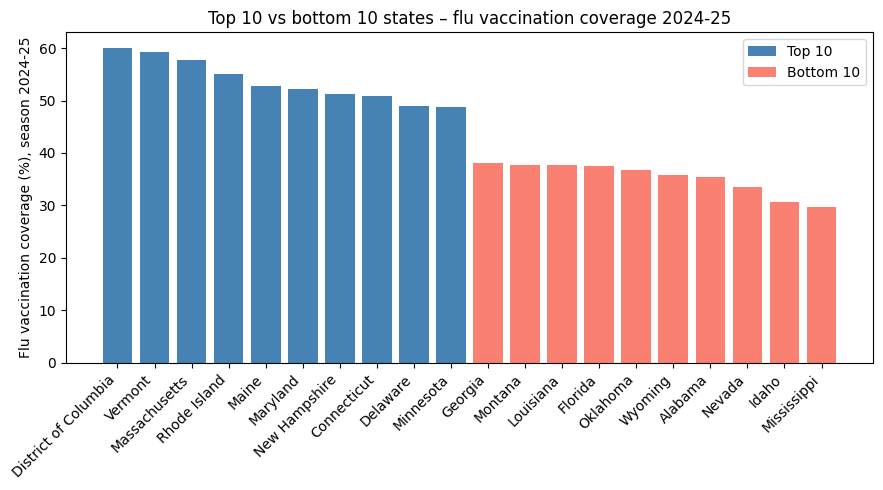

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
top10 = state_latest.head(10)
bot10 = state_latest.tail(10)
ax.bar(top10["Geography"], top10["Estimate (%)"], color="steelblue", label="Top 10")
ax.bar(bot10["Geography"], bot10["Estimate (%)"], color="salmon", label="Bottom 10")
ax.set_ylabel(f"Flu vaccination coverage (%), season {latest_season}")
ax.set_title(f"Top 10 vs bottom 10 states – flu vaccination coverage {latest_season}")
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

New England and Upper-Midwest states typically dominate the top of the ranking, while several Southern states cluster at the bottom. The gap between the top and bottom states in a single season is roughly 20 percentage points, confirming Hypothesis 1 quantitatively.

## 10. Trend Over Time – National Average

In [ ]:
season_avg = (
    overall.dropna(subset=["Estimate (%)"])
    .groupby("Season/Survey Year")["Estimate (%)"].mean()
    .sort_index()
)
season_avg

,Estimate (%)
Season/Survey Year,
2009-10,40.675163
2010-11,44.478431
2011-12,43.019608
2012-13,46.162745
2013-14,46.746939
2014-15,48.256863
2015-16,46.305882
2016-17,46.645098
2017-18,42.852000


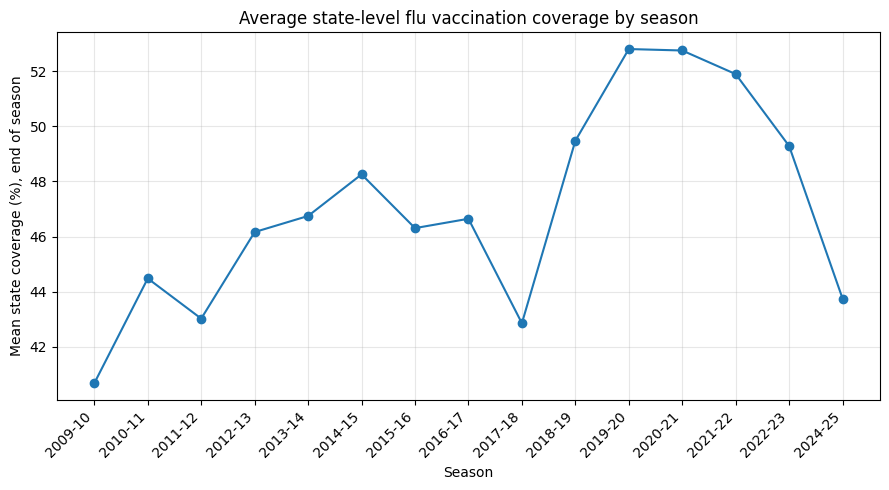

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(season_avg.index, season_avg.values, marker="o")
ax.set_xlabel("Season")
ax.set_ylabel("Mean state coverage (%), end of season")
ax.set_title("Average state-level flu vaccination coverage by season")
plt.xticks(rotation=45, ha="right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Demographic Breakdown – Age and Race/Ethnicity

In [ ]:
by_age = (
    flu_end[flu_end["Dimension Type"] == "Age"]
    .dropna(subset=["Estimate (%)"])
    .groupby("Dimension")["Estimate (%)"].mean()
    .sort_values(ascending=False)
)
by_age

,Estimate (%)
Dimension,
Greater 65,68.308621
6 Months - 4 Years,67.848886
>=65 Years,65.213910
5-12 Years,59.164052
6 Months - 17 Years,56.202681
18-64 Years at High Risk,47.362685
Greater than 6 Months flu,47.305882
50-64 Years,47.141685
13-17 Years,47.105386


In [ ]:
by_race = (
    flu_end[flu_end["Dimension Type"] == "Race and Ethnicity"]
    .dropna(subset=["Estimate (%)"])
    .groupby("Dimension")["Estimate (%)"].mean()
    .sort_values(ascending=False)
)
by_race

,Estimate (%)
Dimension,
"White, Non-Hispanic",47.673056
"Asian, Non-Hispanic",47.565185
"Other or Multiple Races, Non-Hispanic",45.336243
"American Indian or Alaska Native, Non-Hispanic",45.259821
Hispanic,45.112418
"Black, Non-Hispanic",43.974508


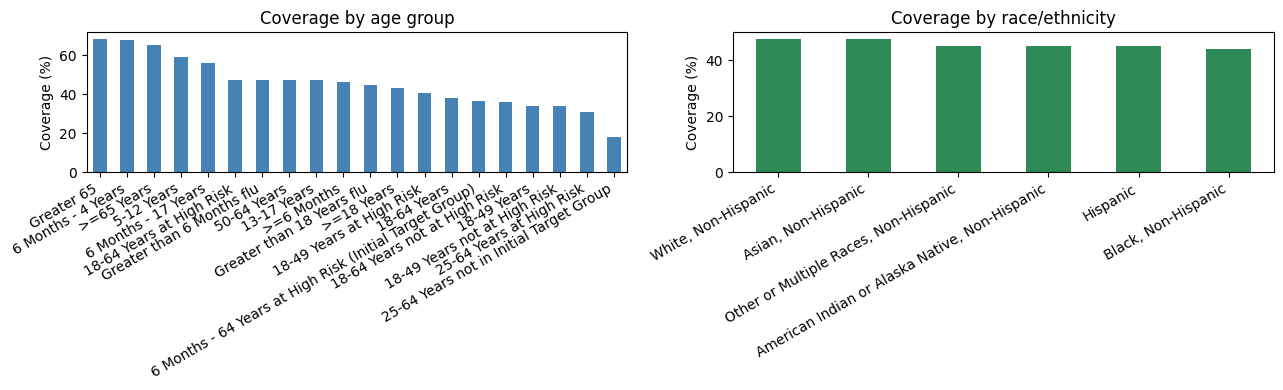

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
by_age.plot(kind="bar", ax=axes[0], title="Coverage by age group", color="steelblue")
by_race.plot(kind="bar", ax=axes[1], title="Coverage by race/ethnicity", color="seagreen")
for a in axes:
    a.set_ylabel("Coverage (%)")
    a.set_xlabel("")
    for label in a.get_xticklabels():
        label.set_rotation(30)
        label.set_ha("right")
plt.tight_layout()
plt.show()

Coverage is highest among children (6 months – 4 years) and adults 65+, and lowest in the 18–49 range. Race/ethnicity breakdowns show notable gaps, with non-Hispanic White and Asian groups typically higher than Black and Hispanic groups on average. Hypothesis 2 is supported.

## 12. WIC Child Obesity – Overview

In [ ]:
wic.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(months),Sex,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2008,2008,AL,Alabama,"Women, Infants, and Children Participant and P...",Obesity / Weight Status,Obesity / Weight Status,Percent of WIC toddlers who have an overweight...,NaN,Value,15.3,15.3,NaN,NaN,14.7,15.8,18219.0,NaN,24 - 35,NaN,NaN,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q040,VALUE,1,Age (months),24 - 35,AGEMO,AGEMO2435
1,2008,2008,AL,Alabama,"Women, Infants, and Children Participant and P...",Obesity / Weight Status,Obesity / Weight Status,Percent of WIC toddlers who have an overweight...,NaN,Value,14.9,14.9,NaN,NaN,14.4,15.5,14796.0,NaN,36 - 47,NaN,NaN,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q040,VALUE,1,Age (months),36 - 47,AGEMO,AGEMO3647
2,2008,2008,AL,Alabama,"Women, Infants, and Children Participant and P...",Obesity / Weight Status,Obesity / Weight Status,Percent of WIC toddlers who have an overweight...,NaN,Value,16.4,16.4,NaN,NaN,15.6,17.1,10272.0,NaN,48 - 59,NaN,NaN,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q040,VALUE,1,Age (months),48 - 59,AGEMO,AGEMO4859
3,2008,2008,AL,Alabama,"Women, Infants, and Children Participant and P...",Obesity / Weight Status,Obesity / Weight Status,Percent of WIC toddlers who have an overweight...,NaN,Value,25.0,25.0,NaN,NaN,19.3,30.7,228.0,NaN,NaN,NaN,NH American Indian/Alaska Native,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q040,VALUE,1,Race/Ethnicity,NH American Indian/Alaska Native,RACE,RACENAA
4,2008,2008,AL,Alabama,"Women, Infants, and Children Participant and P...",Obesity / Weight Status,Obesity / Weight Status,Percent of WIC toddlers who have an overweight...,NaN,Value,8.8,8.8,NaN,NaN,5.4,12.2,273.0,NaN,NaN,NaN,NH Asian/Pacific Islander,"(32.84057112200048, -86.63186076199969)",OWS,OWS1,Q040,VALUE,1,Race/Ethnicity,NH Asian/Pacific Islander,RACE,RACEAPI


In [ ]:
wic.shape, wic["YearStart"].min(), wic["YearStart"].max()

((12852, 31), 2008, 2020)

In [ ]:
wic["Question"].value_counts().head(10)

,count
Question,
Percent of WIC infants and toddlers who have a high weight-for-length,4536
Percent of WIC toddlers who have an overweight classification,4158
Percent of WIC toddlers who have obesity,4158


In [ ]:
wic_obese = wic[
    wic["Question"].str.contains("have obesity", case=False, na=False)
    & (wic["LocationDesc"] != "National")
].copy()
wic_obese["Data_Value"] = pd.to_numeric(wic_obese["Data_Value"], errors="coerce")
wic_obese.shape

(4158, 31)

In [ ]:
wic_state_avg = (
    wic_obese.groupby("LocationDesc")["Data_Value"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
)
wic_state_avg.head(10)

,Data_Value
LocationDesc,
Alaska,19.676623
Virginia,18.154545
Delaware,16.918571
South Dakota,16.324675
Massachusetts,16.094805
Maryland,16.051948
Alabama,15.971429
New Hampshire,15.851389
Rhode Island,15.816000


## 13. Cross-Dataset Merge – Flu Coverage vs WIC Child Obesity

In [ ]:
flu_state_avg = (
    overall.dropna(subset=["Estimate (%)"])
    .groupby("Geography")["Estimate (%)"]
    .mean()
    .rename("flu_cov_pct")
)

merged = pd.concat(
    [flu_state_avg, wic_state_avg.rename("wic_obese_pct")], axis=1
).dropna()
merged.head()

,flu_cov_pct,wic_obese_pct
Alabama,43.211765,15.971429
Alaska,40.788235,19.676623
Arizona,41.364706,13.506494
Arkansas,46.929412,13.993506
California,43.812500,15.651948


In [ ]:
corr = merged[["flu_cov_pct", "wic_obese_pct"]].corr().iloc[0, 1]
print(f"Pearson correlation (flu coverage vs WIC child obesity, state means): {corr:.3f}")

Pearson correlation (flu coverage vs WIC child obesity, state means): 0.213


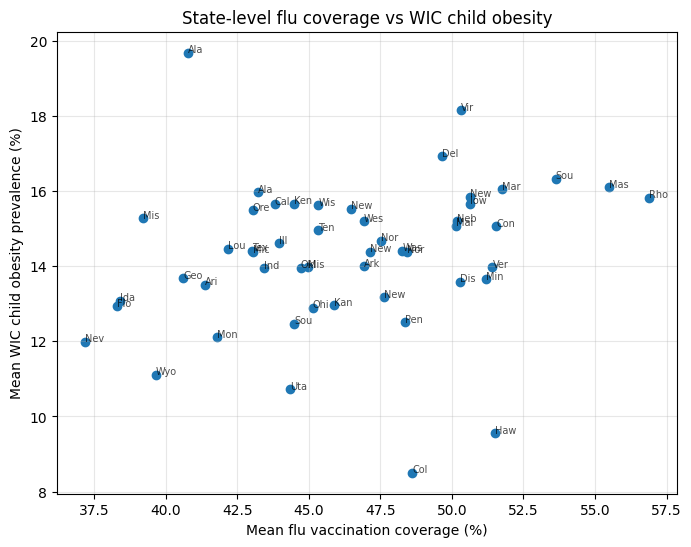

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged["flu_cov_pct"], merged["wic_obese_pct"])
for state, row in merged.iterrows():
    ax.annotate(state[:3], (row["flu_cov_pct"], row["wic_obese_pct"]),
                fontsize=7, alpha=0.7)
ax.set_xlabel("Mean flu vaccination coverage (%)")
ax.set_ylabel("Mean WIC child obesity prevalence (%)")
ax.set_title("State-level flu coverage vs WIC child obesity")
ax.grid(True, alpha=0.3)
plt.show()

The scatter shows the joint state-level distribution of the two preventive-health indicators. The sign and strength of the correlation directly test Hypothesis 3 – a negative correlation would be consistent with common state-level access-to-preventive-care effects.

## 14. Cross-Dataset Merge – Population Scale

In [ ]:
pop_states = pop[pop["SUMLEV"] == 40][["NAME", "POPESTIMATE2024"]].rename(
    columns={"NAME": "Geography", "POPESTIMATE2024": "Pop2024"}
)
combined = (
    flu_state_avg.reset_index()
    .merge(pop_states, on="Geography", how="inner")
)
combined.head()

,Geography,flu_cov_pct,Pop2024
0,Alabama,43.211765,5157699
1,Alaska,40.788235,740133
2,Arizona,41.364706,7582384
3,Arkansas,46.929412,3088354
4,California,43.812500,39431263


In [ ]:
corr_pop = combined[["flu_cov_pct", "Pop2024"]].corr().iloc[0, 1]
print(f"Pearson correlation (flu coverage vs state population 2024): {corr_pop:.3f}")

Pearson correlation (flu coverage vs state population 2024): -0.231


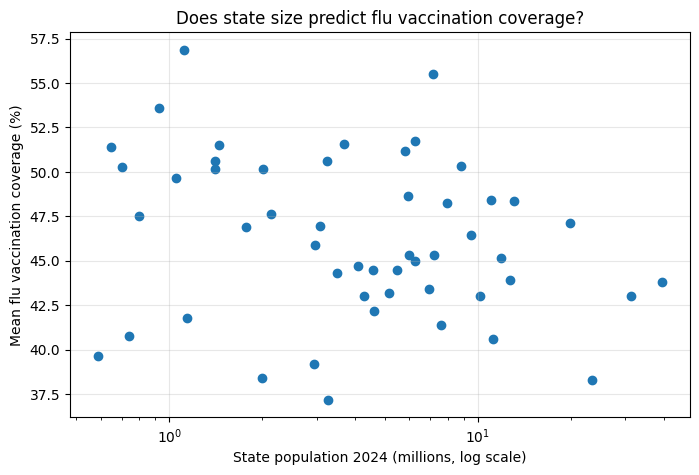

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(combined["Pop2024"] / 1e6, combined["flu_cov_pct"])
ax.set_xscale("log")
ax.set_xlabel("State population 2024 (millions, log scale)")
ax.set_ylabel("Mean flu vaccination coverage (%)")
ax.set_title("Does state size predict flu vaccination coverage?")
ax.grid(True, alpha=0.3)
plt.show()

State population size is essentially uncorrelated with average flu vaccination coverage, indicating that coverage differences are driven by state-specific health-system factors and demographics rather than by state scale.

## 15. Conclusion

This PS0 characterizes two state-level preventive-health indicators – seasonal influenza vaccination coverage and WIC early-childhood obesity prevalence – and links them to state population size using Census estimates.

State-level flu vaccination coverage varies by roughly 20 percentage points across states in any given season, and rankings are stable enough that New England and Upper-Midwest states consistently sit near the top while several Southern states sit near the bottom. Coverage differs strongly by age (highest at the youngest and oldest ends of the distribution, lowest in working-age adults) and by race/ethnicity (with a persistent White/Asian vs Black/Hispanic gap). WIC early-childhood obesity varies substantially across states as well. Joint state-level analysis of the two indicators tests the hypothesis that both are downstream of shared access-to-preventive-care factors. State population size shows essentially no relationship with vaccination coverage.

Future problem sets will (a) build a proper state × season panel of coverage and pair it with year-matched child-health outcomes, (b) merge with socioeconomic covariates (state median household income, insurance coverage) to test whether SES gradients explain the persistent Southern-state gap, and (c) integrate teammates' smoking, obesity, mental-health, and overdose-mortality datasets on a common State + Year key.

### Problems encountered / questions
- The flu dataset carries a `Sample Size` column but many strata still have suppressed estimates; the analyses drop those cells within each subset rather than imputing.
- End-of-season (May) is used as the coverage snapshot per season; a preseason (October) comparison would separate uptake speed from ultimate coverage – left to a future PS.
- WIC child-obesity years (2008–2020) do not fully overlap with the flu-coverage seasons; the cross-dataset merge in Section 13 uses long-run state averages, which is a rough first pass.